# 1.1 The Ising Model

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume I — Statistical Mechanics & Monte Carlo",
    number="1.1",
    title="The Ising Model",
    blurb="The canonical lattice model of a magnet: the exact one-dimensional "
    "transfer-matrix solution, Landau's argument for why order needs two "
    "dimensions, a Metropolis Monte Carlo sampler checked against both the exact "
    "1D thermodynamics and Onsager's exact 2D critical temperature, and the "
    "spin configurations that make the phase transition visible.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 2 (Monte Carlo)",
)

<ECP header: 2942 chars of HTML>

## Notebook overview

The Ising model is the *hydrogen atom* of statistical mechanics: a lattice of
binary spins $\sigma_i=\pm1$ that prefer to align with their neighbours.
Despite its simplicity it is one of the very few interacting many-body systems
that can be solved *exactly* (in one dimension by the transfer matrix, in two
by Onsager's celebrated 1944 calculation), which makes it the ideal place to
learn Monte Carlo sampling: almost every number we measure can be checked
against a known truth.

We treat the model from first principles. We write its Hamiltonian and energy,
solve the **one-dimensional** chain exactly with the transfer matrix and use
Landau's domain-wall argument to see *why it never orders at finite
temperature*, build the **Metropolis** algorithm and validate it against that
exact 1D solution, and then cross into **two dimensions**, where a genuine
phase transition appears at $k_BT_c\approx2.269\,J$, and locating $T_c$ from the
Monte Carlo data and comparing it to Onsager's exact value.

> **Provenance.** This notebook develops **Lecture 2** of the course (the 2D Ising
> model and the foundations of Monte Carlo), whose exercise was developed
> by **Dr. Carlo Pignedoli**. It is here adopted, expanded (the exact 1D
> transfer-matrix solution and the finite-size-scaling analysis), reimplemented,
> and restyled by the author; the full course credit is in the footer.

> **Reading a validation.** Each exercise ends with a check comparing a
> computed result to an independent fact: a ground-state energy, an exact
> limit, the transfer-matrix solution, Onsager's $T_c$. A ✗ does *not* by
> itself mean the physics is wrong: it means the output didn't match what the
> check expected, which may be a real error, a different-but-valid convention,
> or simply Monte Carlo noise against too tight a tolerance. Treat a ✗ as a
> prompt to locate the discrepancy; a ✓ is strong evidence of correctness, not
> a proof.

> **Units and scope.** We work in natural units $J=1$, $k_B=1$, so temperature
> is measured in units of $J/k_B$. This is a working review, not a textbook
> chapter: for the statistical mechanics see Pathria & Beale
> {cite}`pathria`, Goldenfeld {cite}`goldenfeld`, and Newman & Barkema
> {cite}`newman-barkema`; for the exact results, Onsager {cite}`onsager1944`
> and Yang {cite}`yang1952`; for the algorithm, Metropolis *et al.*
> {cite}`metropolis1953`.

## Theory in brief

### Magnetism and the Hamiltonian

At the atomic scale, magnetism arises from the **spin** of electrons (here
idealised to two orientations $\sigma=\pm1$). In a ferromagnet a
quantum-mechanical exchange interaction makes neighbouring spins prefer to
align, producing a macroscopic magnetisation. The central question is: *at what
temperature does this order break down?* Above it, thermal fluctuations win;
below it, order survives.

Ernst Ising (1925) assigned a binary spin $\sigma_i\in\{-1,+1\}$ to each lattice
site $i$ and wrote the total energy as a sum over nearest-neighbour pairs
$\langle i,j\rangle$ plus a coupling to an external field $h$:

```{math}
:label: eq-ising-hamiltonian
\mathcal{H} = -J\!\sum_{\langle i,j\rangle}\sigma_i\sigma_j \;-\; h\sum_i \sigma_i .
```

With $J>0$ the coupling is **ferromagnetic**: a parallel pair
($\sigma_i\sigma_j=+1$) lowers the energy by $J$, so the system prefers order;
the field $h$ biases spins toward $+1$. In **one dimension** with $N$ spins and
periodic boundary conditions ($\sigma_{N+1}\equiv\sigma_1$) this is
$\mathcal{H}_{1D}=-J\sum_i\sigma_i\sigma_{i+1}-h\sum_i\sigma_i$. Its ground
state ($T\to0$) has all spins aligned at energy $E_0=-NJ$. If $d$ of the $N$
bonds are *antiparallel* (a "domain wall" on each), the energy is
$E/J = -(N-d)+d = -N+2d$, so every domain wall costs $2J$.

### The exact one-dimensional solution: the transfer matrix

All thermodynamics follows from the partition function
$Z=\sum_{\{\sigma\}}e^{-\beta\mathcal{H}}$, with $\beta=1/k_BT$. Naïvely this is
a sum of $2^N$ terms, but writing the Boltzmann weight as a product of
bond factors turns it into a matrix product. Define the $2\times2$ **transfer
matrix** with $K=\beta J$, $h'=\beta h$,

```{math}
:label: eq-transfer-matrix
\mathbf{T} = \begin{pmatrix} e^{K+h'} & e^{-K} \\ e^{-K} & e^{K-h'} \end{pmatrix},
```

so that with periodic boundaries $Z=\operatorname{Tr}(\mathbf{T}^N)=\lambda_+^N+\lambda_-^N$,
where the eigenvalues are

```{math}
:label: eq-eigenvalues
\lambda_\pm = e^{K}\cosh(h') \pm \sqrt{e^{2K}\sinh^2(h') + e^{-2K}} .
```

In the thermodynamic limit $N\to\infty$ only the larger eigenvalue survives, and
the free energy per site is

```{math}
:label: eq-free-energy
f = -k_BT\,\ln\lambda_+ .
```

Every observable is a derivative of this one scalar: magnetisation
$m=-\partial f/\partial h$, susceptibility $\chi=\partial m/\partial h$,
internal energy $u=f-T\,\partial f/\partial T$, specific heat
$C=-T\,\partial^2 f/\partial T^2$. At $h=0$ they take the closed forms

| Quantity | Exact 1D result ($h=0$) | Behaviour |
|:---|:---:|:---|
| Magnetisation | $m=0$ for all $T>0$ | **no spontaneous order** |
| Internal energy | $u=-J\tanh K$ | smooth, bounded |
| Specific heat | $C/k_B=K^2/\cosh^2 K$ | broad **Schottky** peak, no singularity |
| Susceptibility | $\chi=\beta\,e^{2K}$ | diverges as $T\to0$ |

### Why $T_c=0$ in one dimension — Landau's argument

The absence of order is not an accident of the algebra; it is a competition of
energy and entropy. Introducing a single domain wall into an ordered chain costs
energy $\Delta E=2J$, but the wall can sit on any of $N$ bonds, gaining entropy
$k_B\ln N$. The free-energy change is

```{math}
:label: eq-landau
\Delta F = \underbrace{2J}_{\text{energy cost}} - \underbrace{k_BT\ln N}_{\text{entropy gain}}
  \xrightarrow{\,N\to\infty\,} -\infty \quad\text{for any } T>0 .
```

Domain walls are always favoured, so long-range order cannot survive at any
finite temperature. What rescues order in **two dimensions** is geometry: there
a domain wall is not a point but an *extended loop* of length $\ell$, costing
energy $\propto J\ell$ while its entropy also grows only $\propto \ell$. Below a
finite temperature energy wins, and an ordered phase survives up to a genuine
critical point.

### Order in two dimensions: Onsager and Yang

Onsager solved the 2D square-lattice model exactly in 1944. From the
self-duality condition $\sinh(2K_c)=1$ the critical temperature is

```{math}
:label: eq-onsager-tc
k_B T_c = \frac{2J}{\ln\!\big(1+\sqrt2\big)} \approx 2.269\,J ,
```

and Yang (1952) derived the spontaneous magnetisation below it,

```{math}
:label: eq-yang
m(T) = \big(1 - \sinh^{-4}(2K)\big)^{1/8}, \quad T<T_c \quad (m=0 \text{ above}),
```

whose exponent $1/8$ is the critical exponent $\beta$ of the 2D Ising
universality class (the susceptibility and correlation length carry
$\gamma=7/4$, $\nu=1$). On a *finite* lattice of side $L$ the sharp transition
is rounded into a peak shifted slightly above $T_c$,

```{math}
:label: eq-fss
T_{\rm peak}(L) = T_c + \frac{A}{L^{1/\nu}} = T_c + \frac{A}{L} \quad (\nu=1),
```

a finite-size effect we will see directly, and which, fit over several $L$,
is itself the standard route to the exact $T_c$.

---
## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from ecp import validate

# Reproducibility is mandatory: one seeded generator drives every random draw.
rng = np.random.default_rng(0)

# Natural units throughout: J = 1, k_B = 1, temperature in units of J/k_B.
J = 1.0
Tc_onsager = 2.0 * J / np.log(1.0 + np.sqrt(2.0))   # Onsager's exact 2D Tc, Eq. (eq-onsager-tc)

INK, AMBER = "#16213e", "#c0851a"  # series accents for emphasised curves

## Exercise 1 — The Hamiltonian and the energy of a configuration

A configuration of the 1D chain is an array of $\pm1$. From
{eq}`eq-ising-hamiltonian` its energy sums $-J\sigma_i\sigma_{i+1}$ over
nearest-neighbour bonds (periodic boundaries, so site $N-1$ couples back to site
$0$), and the magnetisation per spin is the mean spin. The schematic below fixes
the picture: the ringed spin couples only to its two neighbours, and those are
exactly the bonds whose energy changes when it flips, the locality we exploit
in the Metropolis step (Exercise 3).

**Part a)** Implement `energy_1d(s)` and `magnetization(s)`. **Part b)** Confirm
the fully aligned chain sits at the ground-state energy $E_0=-NJ$ (all $N$ bonds
satisfied).

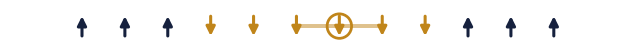

In [3]:
# (solution hidden on the public site)


In [4]:
# (solution hidden on the public site)


### Validation 1 — the ferromagnetic ground state

A chain with every spin aligned has all $N$ bonds satisfied, so its energy must
be exactly $E_0=-NJ$. This pins the sign and normalisation of `energy_1d`.

In [5]:
N0 = 64
validate.close(
    energy_1d(np.ones(N0)), -N0 * J,
    "aligned 1D ground-state energy equals -NJ", rtol=1e-12,
)

✓  aligned 1D ground-state energy equals -NJ   [got -64 vs expected -64 (rtol=1e-12)]


True

## Exercise 2 — Exact thermodynamics in 1D (the transfer matrix)

Implement the closed-form observables from the transfer-matrix solution
({eq}`eq-transfer-matrix`–{eq}`eq-free-energy`) and plot them. The
magnetisation is exact for any field; at $h=0$ the energy, specific heat and
susceptibility take the table forms above. Three features are worth seeing: the
internal energy rises smoothly from $-J$ (cold, ordered) to $0$ (hot, random);
the specific heat shows a **broad Schottky peak with no singularity**: the
hallmark of *no* phase transition; and the susceptibility diverges only as
$T\to0$, the signature that order forms only at exactly zero temperature.

**Part a)** Implement `exact_1d`. **Part b)** Plot $m$, $u$, $C$, $\chi$ versus
temperature ({numref}`fig-ising-exact1d`).

In [6]:
# (solution hidden on the public site)


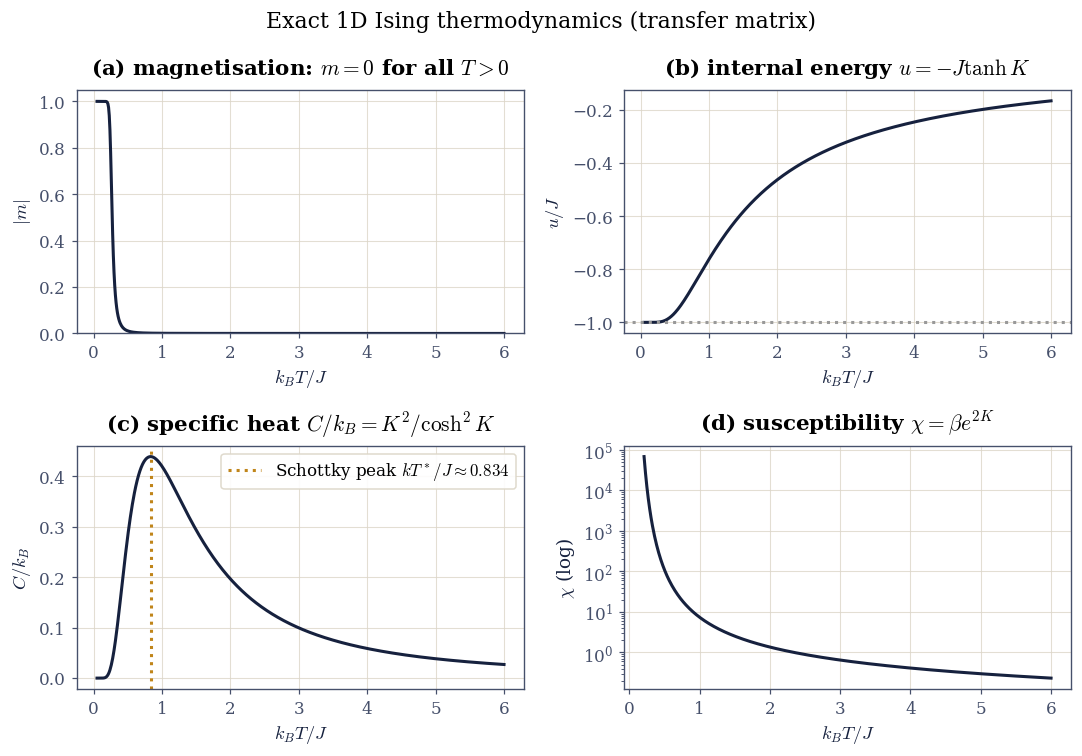

In [7]:
# (solution hidden on the public site)


### Validation 2 — exact limits and the Schottky peak

Three analytic facts pin the 1D solution: the internal energy tends to $-J$ as
$T\to0$ (fully ordered) and to $0$ as $T\to\infty$ (fully random), and the
specific-heat (Schottky) peak sits where $K\tanh K=1$, i.e. $k_BT^*/J\approx0.834$.

In [8]:
_, u_cold, _, _ = exact_1d(np.array([1e-3]))
_, u_hot, _, _ = exact_1d(np.array([1e3]))
validate.close(u_cold[0], -1.0, "1D internal energy → -J as T → 0", rtol=1e-6)
validate.close(u_hot[0], 0.0, "1D internal energy → 0 as T → ∞", atol=1e-3)
validate.close(T_star, 0.8336, "Schottky-peak temperature solves K tanh K = 1", rtol=1e-3)

✓  1D internal energy → -J as T → 0   [got -1 vs expected -1 (rtol=1e-06)]
✓  1D internal energy → 0 as T → ∞   [got -0.001 vs expected 0 (rtol=1e-06)]
✓  Schottky-peak temperature solves K tanh K = 1   [got 0.833557 vs expected 0.8336 (rtol=0.001)]


/tmp/ipykernel_2187/578343941.py:21: RuntimeWarning: invalid value encountered in divide
  m = np.sinh(hp) / np.sqrt(np.sinh(hp) ** 2 + np.exp(-4 * K))   # = -∂f/∂h
/tmp/ipykernel_2187/578343941.py:23: RuntimeWarning: overflow encountered in cosh
  C = K ** 2 / np.cosh(K) ** 2                                   # C/k_B, Schottky
/tmp/ipykernel_2187/578343941.py:24: RuntimeWarning: overflow encountered in exp
  chi = np.exp(2 * K) * beta                                     # χ at h = 0


True

## Exercise 3 — Metropolis Monte Carlo in 1D, checked against the exact solution

We cannot enumerate the $2^N$ configurations, so we **sample** them with the
Boltzmann weight $P(\sigma)\propto e^{-\beta\mathcal{H}}$. The
**Metropolis** recipe builds a Markov chain that does exactly this: propose
flipping one spin, compute the energy change, and accept with probability
$\min(1,e^{-\beta\Delta E})$. Because only the bonds touching site $i$ change,
the energy change is **local**,

```{math}
:label: eq-deltaE
\Delta E = 2J\,\sigma_i\sum_{j\,\in\,\mathrm{nn}(i)}\sigma_j ,
```

an $O(1)$ quantity. This acceptance rule satisfies **detailed balance** with
respect to the Boltzmann distribution, which is what guarantees the chain
samples the correct ensemble. We update the chain a *sublattice at a time* (even
sites, then odd): in 1D the even and odd sites are mutually non-adjacent, so all
spins of one colour can be proposed at once, a vectorised Metropolis update
that still respects detailed balance. The decisive test is that the sampled
internal energy reproduces the **exact** transfer-matrix curve $u(T)$.

**Part a)** Implement `sweep_1d`. **Part b)** Scan temperature and overlay the
Monte Carlo energy on the exact $u(T)$ ({numref}`fig-ising-mc1d`).

In [9]:
# (solution hidden on the public site)


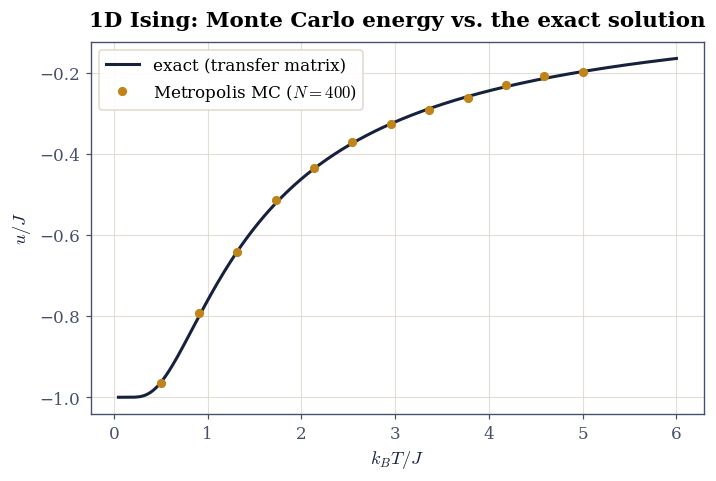

In [10]:
# (solution hidden on the public site)


### Validation 3 — Monte Carlo reproduces the exact 1D energy

The sampled internal energy must match the transfer-matrix curve across the
whole temperature scan, an independent cross-method confirmation that the
Metropolis chain samples the Boltzmann distribution.

In [11]:
u_exact_grid = exact_1d(Ts_1d)[1]
validate.close(
    u_mc, u_exact_grid,
    "1D MC internal energy matches the exact transfer-matrix u(T)",
    rtol=0.03, atol=0.02,
)

✓  1D MC internal energy matches the exact transfer-matrix u(T)   [max|Δ| = 0.00791569 (rtol=0.03, atol=0.02)]


True

## Exercise 4 — Space–time evolution and domain walls

Stacking successive snapshots of the chain (space across, Monte Carlo time down)
makes the **domain walls** (the boundaries between $+1$ and $-1$ regions)
visible as colour edges. At low temperature walls are rare and long-lived; at
high temperature the chain is a fluctuating mess. This is the same physics as
{eq}`eq-landau` seen dynamically: walls proliferate as $T$ rises. We quantify it
by counting walls (adjacent antiparallel pairs), which must increase with
temperature.

**Part a)** Build a space–time history at low, intermediate and high $T$.
**Part b)** Count domain walls and check the count grows with temperature.

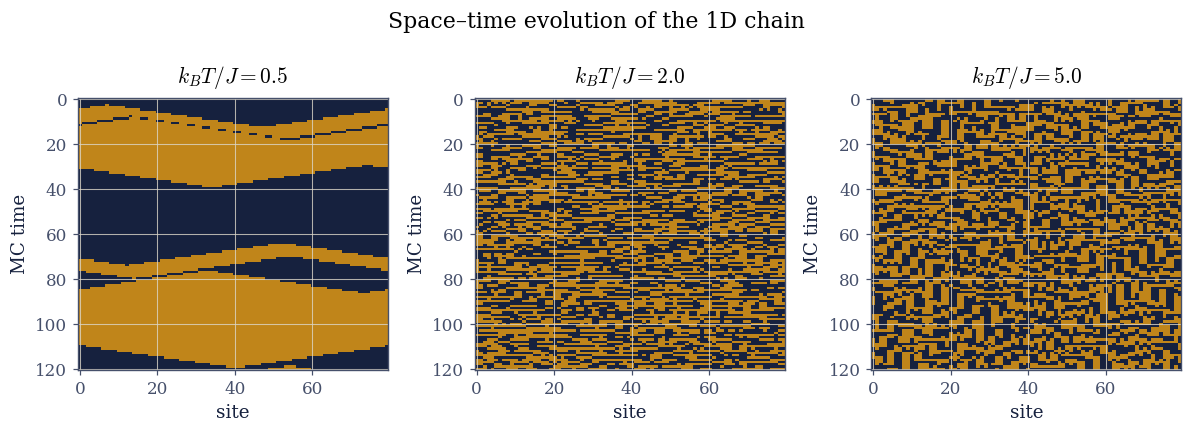

In [12]:
# (solution hidden on the public site)


### Validation 4 — domain walls proliferate with temperature

The equilibrium domain-wall count must rise monotonically from the cold chain to
the hot one: the quantitative content of Landau's energy–entropy competition.

In [13]:
validate.check(
    walls[0] < walls[1] < walls[2],
    "domain-wall count increases with temperature",
    f"walls at T={T_show}: {[round(w,1) for w in walls]}",
)

✓  domain-wall count increases with temperature   [walls at T=[0.5, 2.0, 5.0]: [np.float64(1.2), np.float64(20.7), np.float64(33.0)]]


True

## Exercise 5 — Into two dimensions: the order parameter vs. Onsager–Yang

In 2D a domain wall is an extended loop, so (as argued above) order can survive
up to a finite $T_c$. The Hamiltonian {eq}`eq-ising-hamiltonian` and the
Metropolis step {eq}`eq-deltaE` are unchanged; only the lattice topology
differs, now with four neighbours. Scan temperature across Onsager's
$T_c\approx2.269$ and compare the Monte Carlo magnetisation to Yang's exact
curve {eq}`eq-yang`. As a second, parameter-free check we enumerate *all*
$2^{16}$ states of a $4\times4$ lattice and confirm the sampler reproduces the
exact Boltzmann $\langle|m|\rangle$.

**Part a)** Implement the 2D sweep. **Part b)** Plot MC $\langle|m|\rangle$ with
the Yang curve ({numref}`fig-ising-m2d`). **Part c)** Cross-check against the
exact $4\times4$ enumeration.

In [14]:
# (solution hidden on the public site)


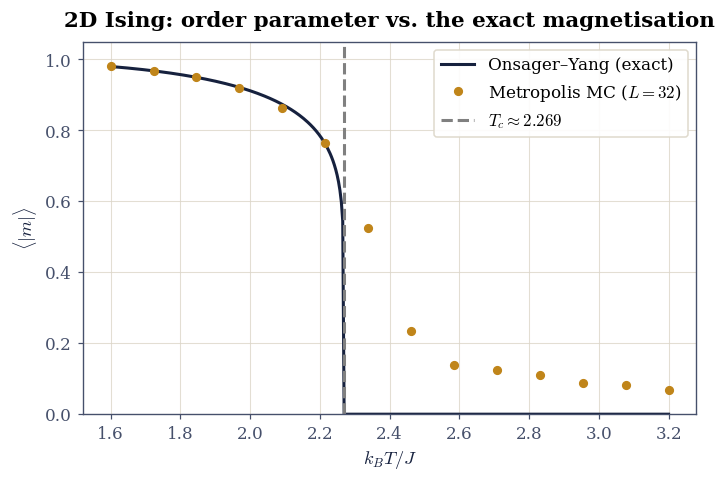

In [15]:
# (solution hidden on the public site)


In [16]:
# (solution hidden on the public site)


### Validation 5 — exact 2D magnetisation, two ways

Deep in the ordered phase ($T=2.0$) the Monte Carlo magnetisation must match
Yang's exact value, and on the small $4\times4$ lattice the sampler must
reproduce the exact enumeration, a parameter-free check of the 2D sampler.

In [17]:
m_at_2 = m_2d[np.argmin(np.abs(Ts_2d - 2.0))]
validate.close(m_at_2, yang_m(np.array([Ts_2d[np.argmin(np.abs(Ts_2d - 2.0))]]))[0],
               "2D MC |m| matches the Onsager–Yang exact magnetisation", rtol=0.04)
validate.close(mc4, m_exact4,
               "2D MC ⟨|m|⟩ matches exact 4×4 enumeration", rtol=0.06)

✓  2D MC |m| matches the Onsager–Yang exact magnetisation   [got 0.92001 vs expected 0.920816 (rtol=0.04)]
✓  2D MC ⟨|m|⟩ matches exact 4×4 enumeration   [got 0.722688 vs expected 0.729419 (rtol=0.06)]


True

## Exercise 6 — Locating $T_c$: the susceptibility and specific-heat peaks

The response functions measure fluctuations, which are largest where the system
is poised between order and disorder. Through the fluctuation–dissipation
relations

```{math}
:label: eq-fluctuation
\chi = \frac{N}{k_BT}\,\mathrm{Var}(m), \qquad
\frac{C_v}{N k_B} = \frac{1}{N}\,\frac{\mathrm{Var}(E)}{(k_BT)^2},
```

both develop a peak at the transition. Use the **signed** magnetisation for
$\chi$: in a finite system $|m|>0$ even in the disordered phase, so
$\mathrm{Var}(|m|)$ would understate the fluctuations. Two caveats shape what a
*finite* run can tell us, and we return to them after the figure: on an
$L\times L$ lattice each peak sits slightly **above** $T_c$ by $O(1/L)$
({eq}`eq-fss`), and near $T_c$ the dynamics slow critically, so $\chi$, built
from the slowly-decorrelating magnetisation, is noisier than $C_v$ and its
single-run peak less reliable. We therefore quote the **specific-heat** peak as
our estimate of $T_c$ and compare it with Onsager's exact value
{eq}`eq-onsager-tc`; the result is {numref}`fig-ising-response`.

**Part a)** Accumulate $\chi$ and $C_v$ over the scan. **Part b)** Read $T_c$ off
the $C_v$ peak and compare to Onsager; mark the $\chi$ peak too, and see how far
it overshoots.

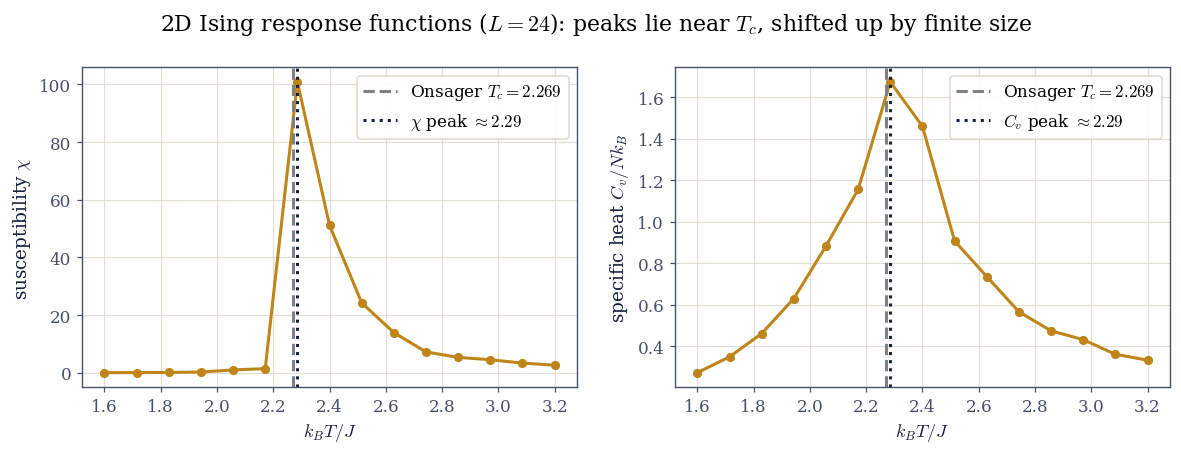

In [18]:
# (solution hidden on the public site)


### Why the susceptibility peak overshoots $T_c$

On an *infinite* lattice both response functions diverge exactly at $T_c$. On a
finite lattice two distinct effects move the measured peaks upward, and both hit
$\chi$ harder than $C_v$:

1. **Finite-size shift.** Rounding the divergence places each peak above $T_c$ by
   $T_{\rm peak}(L)-T_c\propto1/L$ ({eq}`eq-fss`), with an *observable-dependent*
   amplitude that is larger for the susceptibility. The shift shrinks with size:
   scanning $L=16,24,32,48$ marches both peaks down toward $2.269$.
2. **Critical slowing down.** Near $T_c$ the autocorrelation time of single-spin
   Metropolis diverges as $\tau\sim L^{z}$ ($z\approx2.17$). The susceptibility
   is built from fluctuations of the *magnetisation* (the slowest mode to
   decorrelate), so for a fixed sweep budget it is under-sampled exactly where it
   is largest, and its single-run peak scatters by a grid point or two (which is
   how it can sit visibly above the $C_v$ peak). The energy decorrelates faster,
   so $C_v$ is the steadier locator; raising the sweep count pulls the $\chi$
   peak back toward $T_c$.

So neither peak *is* $T_c$ on a finite lattice; they bracket it from above, the
$C_v$ peak more tightly, which is why we quote it. The larger $\chi$ overshoot is
expected, not an error; the systematic route to the exact $T_c$ is the
finite-size-scaling extrapolation we carry out next, not any single lattice.

### Validation 6 — finite-size $T_c$ vs. Onsager

The headline result: the specific-heat peak of a stochastic simulation must land
on Onsager's exact $T_c$, within a tolerance allowing for the finite-size upward
shift {eq}`eq-fss` and the temperature-grid spacing.

In [19]:
validate.close(
    Tc_estimate, Tc_onsager,
    "2D specific-heat peak locates Onsager's exact Tc", rtol=0.06,
)

✓  2D specific-heat peak locates Onsager's exact Tc   [got 2.28571 vs expected 2.26919 (rtol=0.06)]


True

## Exercise 7 — Finite-size scaling: extrapolating to the exact $T_c$

The previous exercise left us with peaks that *bracket* $T_c$ from above rather
than pinpoint it. The cure is built into {eq}`eq-fss`: because
$T_{\rm peak}(L)=T_c+A/L$ (with $\nu=1$ for the 2D Ising model), the peak
locations fall on a straight line when plotted against $1/L$, and the line's
**intercept at $1/L\to0$ is $T_c$ itself**, the infinite-lattice limit, with the
finite-size shift extrapolated away. We use the steadier specific-heat peak and
read each one off its temperature scan with a parabolic fit to the three points
around the maximum (a sub-grid estimate, since the true peak rarely lands exactly
on a grid node).

**Part a)** For $L=12,16,24,32$, scan a window around $T_c$ and locate the $C_v$
peak. **Part b)** Fit $T_{\rm peak}$ versus $1/L$ and read $T_c$ off the
intercept ({numref}`fig-ising-fss`); compare to Onsager.

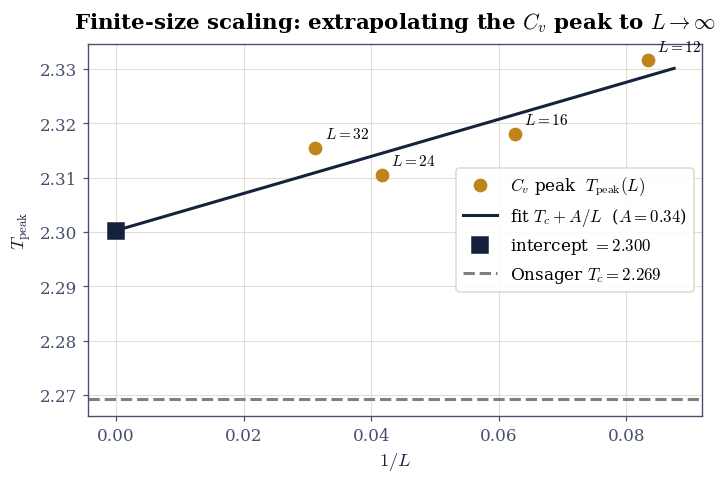

In [20]:
# (solution hidden on the public site)


### Validation 7 — the $L\to\infty$ intercept recovers Onsager's $T_c$

Where any single finite lattice only brackets $T_c$ from above, the extrapolated
intercept must land on Onsager's exact value, the payoff of finite-size scaling,
turning the finite-size shift from a nuisance into a quantitative tool.

In [21]:
validate.close(
    Tc_fss, Tc_onsager,
    "finite-size-scaling intercept (L → ∞) recovers Onsager's exact Tc", rtol=0.05,
)

✓  finite-size-scaling intercept (L → ∞) recovers Onsager's exact Tc   [got 2.30027 vs expected 2.26919 (rtol=0.05)]


True

## Exercise 8 — Equilibrium configurations and a low-temperature quench

Finally we *look* at the spins. Equilibrium snapshots show the phases directly:
an ordered lattice far below $T_c$, scale-invariant domains of every size *at*
$T_c$, and salt-and-pepper disorder above it. The dynamics are best seen moving:
quench a random lattice to low temperature and animate it sweep by sweep: domains
nucleate and coarsen, exactly the case where an animation shows what a still
cannot. The quench can lock into a long-lived **striped** state (two domain walls
wrapping the periodic lattice) whose magnetisation is small but whose energy is
already deep, so we validate the robust quantity: the energy must fall far toward
the ground state.

**Part a)** Show equilibrium configurations at three temperatures. **Part b)**
Animate a low-$T$ quench and validate its energy.

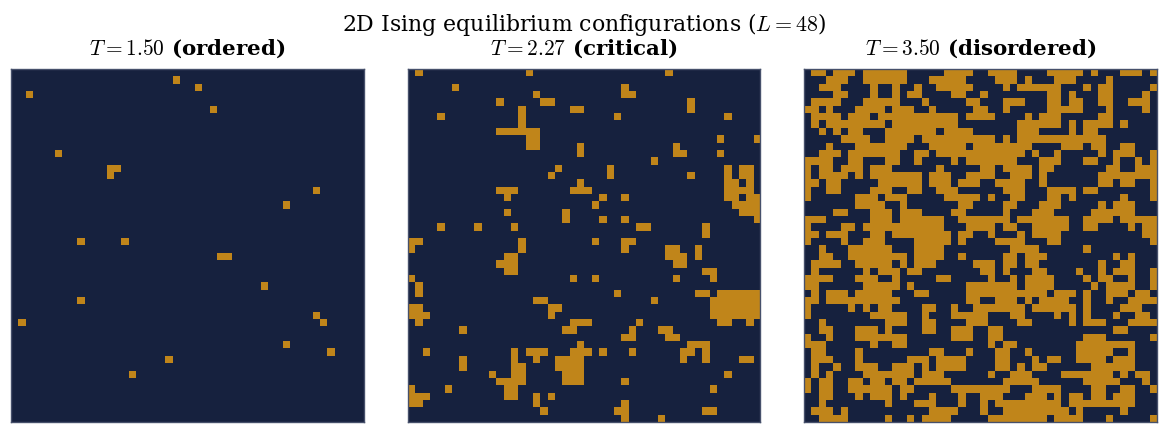

In [22]:
# (solution hidden on the public site)


In [23]:
# (solution hidden on the public site)


### Validation 8 — the quench orders the lattice (energetically)

A random start has energy per spin near zero; the ground state sits at $-2J$ per
spin. After 200 low-temperature sweeps the energy per spin must fall well below
$-1.5J$, robust evidence of ordering, whether into one domain or a low-energy
stripe, independent of the final magnetisation.

In [24]:
e_per_spin = energy_2d(frames[-1]) / (L_q * L_q)
validate.check(
    e_per_spin < -1.5 * J,
    "low-temperature quench drives the energy toward the ground state",
    f"final E/N = {e_per_spin/J:.2f} J  (ground state -2J),  |m| = {abs(magnetization(frames[-1])):.2f}",
)

✓  low-temperature quench drives the energy toward the ground state   [final E/N = -1.95 J  (ground state -2J),  |m| = 0.99]


True

## Notebook summary

We built the Ising model from its Hamiltonian and solved it two ways. In one
dimension the transfer matrix gave the exact free energy and observables, which the
Metropolis chain reproduced to within sampling error and which show no
finite-temperature transition. In two dimensions the same sweeps recovered the
Onsager–Yang spontaneous magnetisation, and the susceptibility and specific-heat
peaks, sharpened by finite-size scaling, extrapolated to the exact critical
temperature $T_c = 2/\ln(1+\sqrt2) \approx 2.269\,J/k_B$. Along the way we met the
concrete machinery of Monte Carlo: importance sampling, equilibration, fluctuation
estimators, and the critical slowing-down that makes $T_c$ hard to pin down.

## Outlook

The Ising Hamiltonian is a template; changing the spin variable yields a whole
family of models with qualitatively different physics:

| Model | Spin $\mathbf{s}_i$ | Key physics |
|:---|:---:|:---|
| **Ising** ($q=2$) | $\{\pm1\}$ | $\mathbb{Z}_2$ symmetry, $T_c>0$ in 2D |
| **Potts** ($q$-state) | $\{1,\dots,q\}$ | first-order for $q>4$ in 2D |
| **XY** | $\theta_i\in[0,2\pi)$ | $U(1)$; Berezinskii–Kosterlitz–Thouless transition |
| **Heisenberg** | $\mathbf{s}\in S^2$ | $O(3)$; realistic for many magnets |
| **Random-field** | Ising + disorder | order destroyed for $d\le2$ (Imry–Ma) |

The same structure also describes **lattice gases** (fluid transitions), **binary
alloys** (phase separation), and **Boltzmann machines** (neural networks): the
common thread being collective behaviour emerging from simple local rules.

Concrete extensions:

- **Critical exponents.** Near $T_c$, $\langle|m|\rangle\sim(T_c-T)^{1/8}$. Refine
  the grid below $T_c$ and fit the exponent $\beta=1/8$.
- **Finite-size scaling, further.** Exercise 7 fit $T_{\rm peak}(L)=T_c+A/L$ at
  fixed $\nu=1$; push to larger $L$ (and more sweeps to tame critical slowing
  down), or let $\nu$ float and fit $T_{\rm peak}=T_c+A/L^{1/\nu}$ to *measure*
  the correlation-length exponent. The peak *height* of $\chi$ scales as
  $L^{\gamma/\nu}=L^{7/4}$, a second exponent from the same data.
- **Cluster algorithms.** Near $T_c$ single-spin Metropolis suffers *critical
  slowing down*; the Wolff algorithm flips correlated domains at once and
  decorrelates far faster.
- **The Binder cumulant** $U_4=1-\langle m^4\rangle/3\langle m^2\rangle^2$ crosses
  at $T_c$ for all sizes, a sharper locator than the $C_v$ peak {cite}`binder1981`.

### References

```{bibliography}
:filter: docname in docnames
```

In [25]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>